# EDA — Telco Customer Churn

## Apresentação

Objetivo: entender o problema antes de modelar. Este notebook explora a taxa de cancelamento (churn) por tipo de contrato, tempo de casa, forma de pagamento e serviços contratados. Além disso, também fazemos uma análise geral sobre os dados, para conhecer mais fundo nosso dataset antes de construir os modelos preditivos.

Dataset: [Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — 7.043 clientes.

In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

raiz_projeto = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd() 

df_inicial = pd.read_csv(raiz_projeto / "data" / "raw" / "telco_customer_churn.csv")
df_inicial.shape

(7043, 21)

Vemos que nossa base bruta tem 7043 observações em 23 variáveis. Vamos dar uma olhada geral nos dados:

In [6]:

df_inicial.dtypes



customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [7]:
df_inicial.duplicated().sum()

np.int64(0)

Não temos linhas duplicadas, o que é ótimo! Significa que cada cliente é único. 

Vemos que a maior parte das colunas tem variáveis qualitativas, o que será um problema quando formos aplicar nossos modelos de predição. Por isso, precisamos tratar os dados. Vamos printar nossos dados:

In [8]:
df_inicial.head(10) 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


## 1. Tratamento dos dados 

Inicialmente, nossa coluna customerID não é uma feature que será útil, podendo ser descartada. Antes disso, vamos fazer uma cópia dos dados iniciais, para caso precisemos recuperá-los em algum momento.

In [9]:
df_tratado = df_inicial.copy() #cria cópia dos dados 

In [10]:
df_tratado = df_tratado.drop(columns=["customerID"])
df_tratado.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


Temos algumas variáveis categórias que serão binárias, como gender, partner, dependents, churn (que será nossa variável target) e outras. A melhor saída para esse caso é fazer um mapeamento para 0, quando não e 1, quando sim. 

In [11]:
colunas_binarias = [
    "Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"
]

for col in colunas_binarias:
    df_tratado[col] = df_tratado[col].map({"Yes": 1, "No": 0})

df_tratado["gender"] = df_tratado["gender"].map({"Male": 1, "Female": 0})

Algumas variáveis podem parecer binárias inicialmente quando vemos o .head, mas possuem uma terceira categoria, vamos confirmar isso através da célula abaixo:

In [12]:
colunas_trescategorias = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

for col in colunas_trescategorias:
    print(f"{col}: {df_tratado[col].unique()}")

OnlineSecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str


Como temos essa terceira categoria "No internet service", precisamos tratar de maneira um pouco diferente. Na prática, dizer que o cliente não tem serviço de internet implica que ele também não terá os serviços de nossas variáveis. Por isso, nesse caso, não precisamos criar uma terceira categoria numérica e podemos forçar que "No internet service" receba "0" como valor. Antes disso, para confirmar nossa hipótese, rodamos o código abaixo, que implica que sempre que InternetService é "No", as outras variáveis não tem observação "Yes". Com isso, podemos substituir por 0 sem problemas.

In [13]:
cols_internet = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                  "TechSupport", "StreamingTV", "StreamingMovies"]

for col in cols_internet:
    print(col)
    print(pd.crosstab(df_tratado["InternetService"], df_tratado[col]))
    print()

OnlineSecurity
OnlineSecurity     No  No internet service   Yes
InternetService                                 
DSL              1241                    0  1180
Fiber optic      2257                    0   839
No                  0                 1526     0

OnlineBackup
OnlineBackup       No  No internet service   Yes
InternetService                                 
DSL              1335                    0  1086
Fiber optic      1753                    0  1343
No                  0                 1526     0

DeviceProtection
DeviceProtection    No  No internet service   Yes
InternetService                                  
DSL               1356                    0  1065
Fiber optic       1739                    0  1357
No                   0                 1526     0

TechSupport
TechSupport        No  No internet service   Yes
InternetService                                 
DSL              1243                    0  1178
Fiber optic      2230                    0   866
No  

Vemos que sempre que temos No internet Service, nosso resultado é No, confirmando nossa ideia de substituir por 0. Vamos lá:

In [14]:
for col in colunas_trescategorias:
    df_tratado[col] = df_tratado[col].replace("No internet service", "No").map({"Yes": 1, "No": 0})




In [15]:
df_tratado[colunas_binarias + colunas_trescategorias].isna().sum() #conferindo se funcionou

Partner             0
Dependents          0
PhoneService        0
PaperlessBilling    0
Churn               0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64

Outro problema que temos que resolver na base é a variável TotalCharges, que veio como string. Para isso, vamos converter ela para float:

In [16]:
df_tratado["TotalCharges"] = pd.to_numeric(df_tratado["TotalCharges"], errors="coerce")


In [17]:
df_tratado.isna().sum()[df_tratado.isna().sum() > 0]

TotalCharges    11
dtype: int64

São 11 clientes com valores nulos em total charges. Podemos postular a hipótese de que são clientes que acabaram de entrar e ainda não fecharam o primeiro ciclo de cobrança. Para confirmar, precisamos comparar com a variável Tenure, que diz há quantos meses o cliente é assinante. Se o max e o min for 0, confirmamos nossa hipótese.

In [18]:
df_tratado[df_tratado["TotalCharges"].isna()]["tenure"].describe()

count    11.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: tenure, dtype: float64

Confirmamos nossa hipótese. Diante disso, precisamos ou preencher com 0 ou descartar essas linhas. Prós e contras são:

- Se preenchemos com 0, estamos "criando" um dado. Porém, isso faz sentido, pois se a pessoa ainda não fechou um ciclo de cobrança, ela realmente tem tenure 0! 
- Se descartamos, não temos grande prejuízo estatístico, pois são somente 11 linhas em 7.043. Porém, é interessante ver se a probabilidade de churn não é mais alta justamente nesses casos em que a pessoa não fechou um ciclo de cobrança. Portanto, vamos ficar com a opção de preencher com 0

In [19]:
df_tratado["TotalCharges"] = df_tratado["TotalCharges"].fillna(0)

In [ ]:
df_tratado.duplicated().sum() #Essa célula mostra que temos algumas linhas duplicadas, mas isso não é um problema, pois no começo da análise confirmamos que não há clientes duplicados. 

#É razoável assumir que em mais de 7.000 observações sem o identificador único, algumas sejam totalmente iguais.  


np.int64(22)

In [21]:
df_tratado.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines           str
InternetService         str
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract                str
PaperlessBilling      int64
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

## 2. Análise Exploratória

Primeiro, temos que ver qual a média de churn, ou seja, a proporção de "Yes" (1) na variável Churn. Isso vai servir para depois analisarmos a proporção de churn em grupos específicos.


In [22]:
base_rate = (df_tratado["Churn"] == 1).mean()
base_rate

np.float64(0.2653698707936959)

Nossa média geral de churn é 26,5%. Isso implica que nossa base vai precisar de balanceamento quando formos fazer o pipeline de treino do modelo preditivo. Por enquanto, vamos seguir explorando nossas variáveis.

## 2.1. Variáveis Numéricas

 Nossas variáveis que eram numéricas inicialmente são tenure, MonthlyCharges e TotalCharges. Vamos plotá-las para ver se tiramos algum insight:

In [23]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

df_tratado[num_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


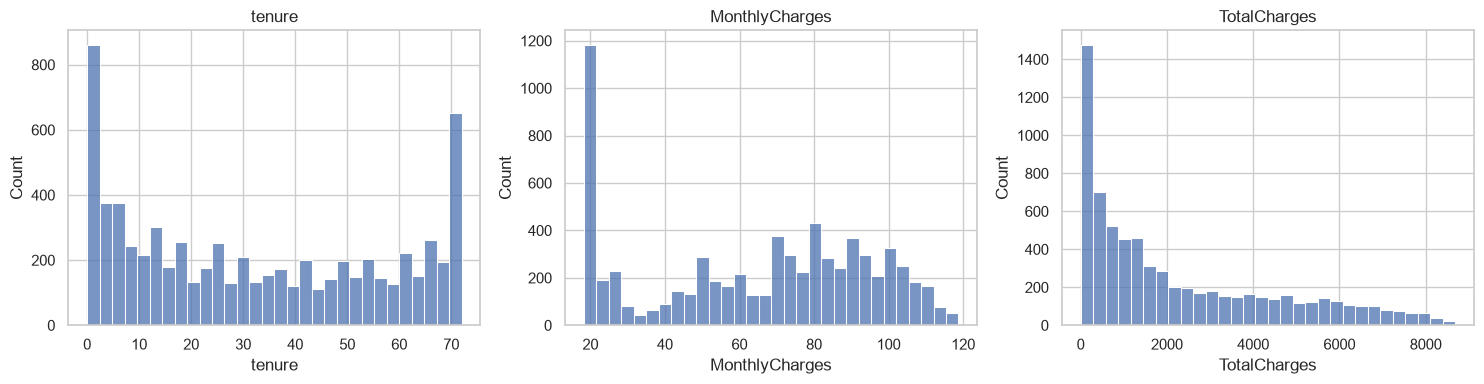

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, num_cols):
    sns.histplot(data=df_tratado, x=col, bins=30, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

Podemos tirar algumas conclusões desses resultados:

- tenure apresenta uma distribuição bimodal. Pico grande perto de 0 (muitos clientes bem novos) e outro pico perto de 70-72, que são clientes há muito tempo. Temos dois grupos distintos, que possivelmente apresentarão comportamento de churn distinto. Tem um desvio padrão alto em relação à média, o que corrobora a bimodalidade vista no histograma.

- MonthlyCharges — não é bimodal clássico, mas é uma mistura de dois grupos. Tem um pico isolado forte perto de 20 (provavelmente clientes só com telefone, sem internet, cobrança baixa e fixa) e depois uma distribuição mais larga concentrada entre 70-100 (provavelmente clientes com internet + serviços adicionais). A mediana (70,35) é maior que a média (~65), o que faz sentido tendo em vista que a concentração de observações em torno de 20 puxa a média para baixo com a maior parte das observações estando na faixa mais alta (70-100)

- TotalCharges é fortemente assimétrico à direita (cauda longa). Esperado, já que TotalCharges ≈ tenure × MonthlyCharges: herda o pico perto de 0 do tenure baixo, e a cauda longa vem dos clientes antigos acumulando cobrança. Essa variável é quase redundante com tenure, quando formos decidir nosos modelo preditivo, se formos usar modelo linear, um log1p(TotalCharges) ajudaria a normalizar; para LightGBM isso importa bem menos.

- Nenhum dos três parece ter outlier absurdo ou erro de dado, com os ranges fazendo sentido (tenure 0-72 meses, MonthlyCharges 18-119, TotalCharges 0-8684, coerente com o produto dos outros dois).

## 2.2. Variáveis Categóricas

É interessante estudar nossas variáveis categóricas para tirar algumas conclusões:

1. Detectar categorias raras antes de confiar em qualquer churn rate por categoria 
2. Detectar problemas de qualidade dos dados 
3. Identificar colunas quase constantes

Em 1, precisamos ver a quantidade de clientes por categoria antes de considerar qualquer resultado como confiável. Se temos 50 clientes e 40% de churn, isso é menos confiável do que uma outra categoria com 2000 clientes e 30% de churn, por exemplo. 

No item 2, precisamos garantir que não há categorias diferentes das pré-estabelecidas, que poderiam ser oriundas de bugs ou erros de digitação. vazemos isso usando value_counts()

No item 3, se uma categórica tiver, por exemplo, mais de 90% das observações em uma única categoria, essa coluna vai ter muito pouco valor preditivo. Podemos anotar como uma candidata a uma feature fraca para lá na frente, quando modelarmos, termos isso em mente. Features muito equilibradas também podem sofrer de baixo poder preditivo.

In [25]:
cat_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "PhoneService", "MultipleLines", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod"
]

for col in cat_cols:
    print(df_tratado[col].value_counts(normalize=True))
    print()

gender
1    0.504756
0    0.495244
Name: proportion, dtype: float64

SeniorCitizen
0    0.837853
1    0.162147
Name: proportion, dtype: float64

Partner
0    0.516967
1    0.483033
Name: proportion, dtype: float64

Dependents
0    0.700412
1    0.299588
Name: proportion, dtype: float64

PhoneService
1    0.903166
0    0.096834
Name: proportion, dtype: float64

MultipleLines
No                  0.481329
Yes                 0.421837
No phone service    0.096834
Name: proportion, dtype: float64

InternetService
Fiber optic    0.439585
DSL            0.343746
No             0.216669
Name: proportion, dtype: float64

OnlineSecurity
0    0.713332
1    0.286668
Name: proportion, dtype: float64

OnlineBackup
0    0.655119
1    0.344881
Name: proportion, dtype: float64

DeviceProtection
0    0.656112
1    0.343888
Name: proportion, dtype: float64

TechSupport
0    0.709783
1    0.290217
Name: proportion, dtype: float64

StreamingTV
0    0.615647
1    0.384353
Name: proportion, dtype: float64

S

In [26]:
limiar = 0.05

for col in cat_cols:
    props = df_tratado[col].value_counts(normalize=True)
    raras = props[props < limiar]
    if not raras.empty:
        print(f"{col} — categorias raras (<{limiar:.0%}):")
        print(raras)
    else:
        print(f"{col} — nenhuma rara")
    print()

gender — nenhuma rara

SeniorCitizen — nenhuma rara

Partner — nenhuma rara

Dependents — nenhuma rara

PhoneService — nenhuma rara

MultipleLines — nenhuma rara

InternetService — nenhuma rara

OnlineSecurity — nenhuma rara

OnlineBackup — nenhuma rara

DeviceProtection — nenhuma rara

TechSupport — nenhuma rara

StreamingTV — nenhuma rara

StreamingMovies — nenhuma rara

Contract — nenhuma rara

PaperlessBilling — nenhuma rara

PaymentMethod — nenhuma rara



Conclusões que podemos tirar dessas informações:

Rodando `value_counts(normalize=True)` para todas as colunas categóricas (demográficas, serviços, contrato e pagamento), o achado mais importante é negativo: **nenhuma categoria, em nenhuma coluna, ficou abaixo do limiar de 5%**. A categoria mais rara da base é `PhoneService == 0` (sem telefone), com ainda assim 9,68% dos clientes. Isso significa que qualquer comparação de taxa de churn por categoria feita na próxima etapa (bivariada) pode ser interpretada com confiança.

**Demográficas:** `gender` (50,5%/49,5%) e `Partner` (51,7%/48,3%) saem praticamente equilibrados. Isso reforça a hipótese  de que, sozinhas, tendem a ser variáveis fracas para prever churn. Já `SeniorCitizen` (83,8% não idosos) e `Dependents` (70% sem dependentes) mostram uma base concentrada em um perfil específico de cliente, mas ainda com volume suficiente no grupo minoritário para comparação.

**Serviços de internet:** a proporção de `"No internet service"` se repete de forma idêntica (21,67%) em todas as seis colunas de add-on (`OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`) — consistente com a relação de implicação já validada por crosstab com `InternetService`. Dentro de quem tem internet, o padrão de adoção varia: `OnlineSecurity` e `TechSupport` têm mais recusa (~50% "No" (0) vs. ~29% "Yes" (1)), enquanto `StreamingTV` e `StreamingMovies` ficam quase empatados entre adotar e não adotar — sugere que streaming é um add-on mais popular que segurança/suporte técnico.

**Contrato:** mais da metade da base (55%) está no plano `Month-to-month`, contra 24% em `Two year` e 21% em `One year`. Isso é relevante porque, pela análise de tenure, sabemos que contrato flexível tende a concentrar o maior risco de churn e mais da metade dos clientes está no segmento potencialmente mais volátil.

**Pagamento:** distribuição relativamente equilibrada entre os quatro métodos, com `Electronic check` levemente à frente (33,6%) dos demais (~22% cada). Nenhum método é residual o suficiente para preocupar na análise seguinte.

## 2.3. Análise de Churn por categoria 


In [31]:
taxa_base = df_tratado["Churn"].mean()

def taxa_churn_por_categoria(col, df=df_tratado):
    resumo = (
        df.groupby(col)["Churn"]           # agrupa os clientes pela categoria da coluna
        .agg(taxa_churn="mean", n="size")  # taxa_churn = média de 0/1 (proporção de Churn==1); n = qtd de clientes no grupo
        .sort_values("taxa_churn", ascending=False)  # ordena da categoria de maior para a de menor risco
    )
    return resumo


def plot_churn_rate(col, df=df_tratado, taxa_base=taxa_base):
    resumo = taxa_churn_por_categoria(col, df)  # taxa de churn e n por categoria, já ordenado

    fig, ax = plt.subplots(figsize=(6, 0.5 * len(resumo) + 1.5))  # altura cresce com o número de categorias

    # rótulo do eixo y já leva o n junto — assim ele não compete com o texto da taxa na ponta da barra
    rotulos_eixo_y = [f"{cat} (n={n})" for cat, n in zip(resumo.index.astype(str), resumo["n"])]

    bars = ax.barh(rotulos_eixo_y, resumo["taxa_churn"], color="#4C72B0")  # uma barra horizontal por categoria

    ax.axvline(taxa_base, color="red", linestyle="--", label=f"Taxa base ({taxa_base:.1%})")  # referência: taxa geral

    for bar, taxa in zip(bars, resumo["taxa_churn"]):
        # escreve o valor exato da taxa de churn na ponta de cada barra
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, f"{taxa:.1%}", va="center", fontsize=9)

    ax.invert_yaxis()  # mantém a categoria de maior risco no topo
    ax.set_xlabel("Taxa de churn")
    ax.set_title(col)
    ax.legend()
    plt.tight_layout()
    plt.show()


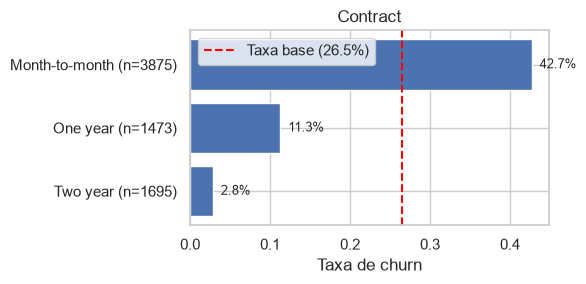

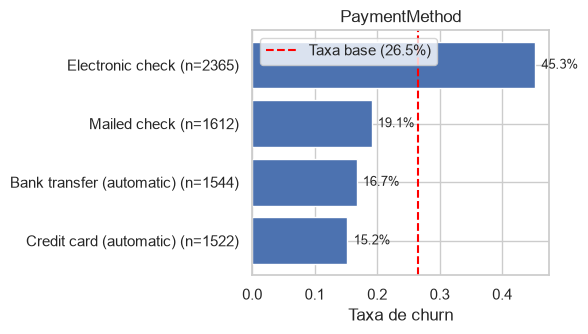

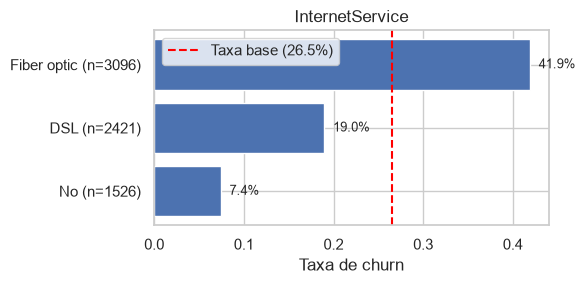

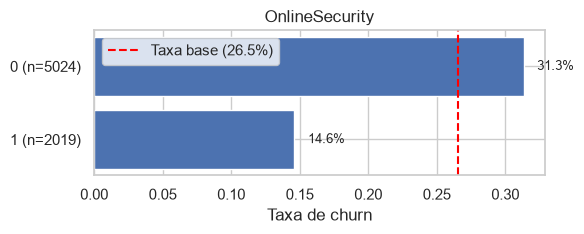

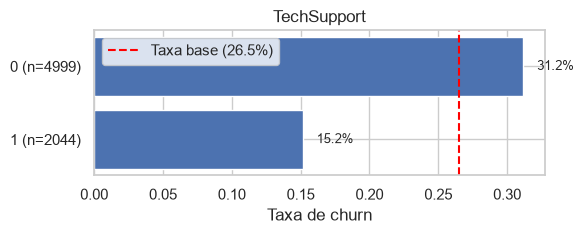

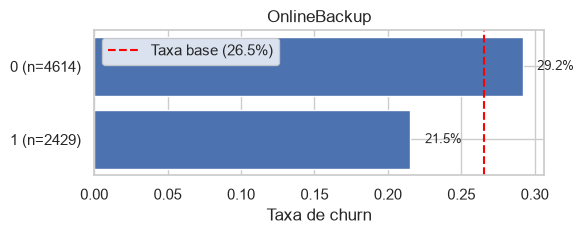

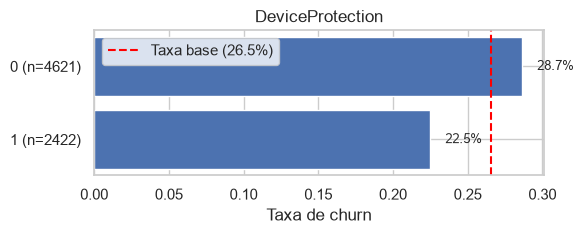

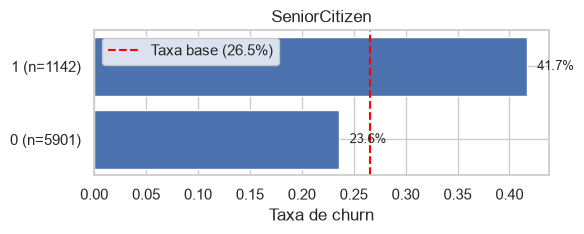

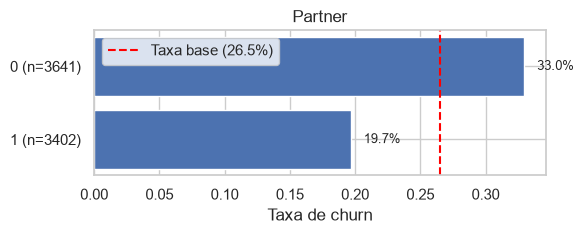

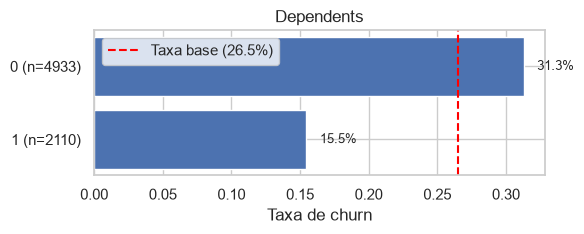

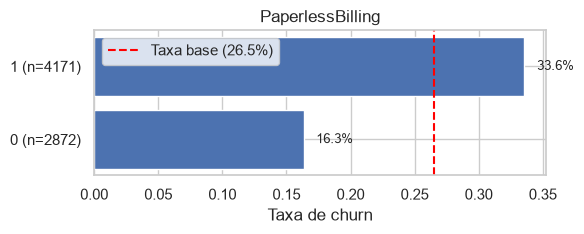

In [28]:
cols_bivariada = [
    "Contract", "PaymentMethod", "InternetService",
    "OnlineSecurity", "TechSupport", "OnlineBackup", "DeviceProtection",
    "SeniorCitizen", "Partner", "Dependents", "PaperlessBilling"
]

for col in cols_bivariada:
    plot_churn_rate(col)

Alguns achados dessa seção:

Contrato é o sinal mais forte dos nosso dados. A variação na proporção de churn é grande pelo tipo de contrato: 42.7% (mês a mês) → 11.3% (um ano) → 2.8% (dois anos), contra uma base de 26.5%. Isso sugere uma leitura de negócio direta: contrato de fidelidade é um ótimo mecanismo de retenção, e provavelmente será uma das features principais de predição do modelo.

Fiber optic com churn mais alto que DSL é o achado contra-intuitivo mais interessante (41.9% vs 19.0%, sendo que fibra é tecnicamente o serviço "melhor"). Isso pode ser por causa do preço: a fibra é significativamente mais cara. Vale conferir MonthlyCharges por tipo de internet para confirmar a hipótese de preço antes de generalizar.

Os quatro add-ons (OnlineSecurity, TechSupport, OnlineBackup, DeviceProtection) têm o mesmo padrão, mas em intensidades diferentes. OnlineSecurity e TechSupport têm o efeito mais forte (~2x de diferença entre ter e não ter o serviço); OnlineBackup e DeviceProtection têm gap menor. Ponto de atenção: essas quatro variáveis tendem a ser correlacionadas entre si (cliente que assina um add-on tende a assinar os outros) e todas dependem de ter internet contratada, então parte do efeito pode estar sendo "roubado" de InternetService. 

O perfil demográfico/domiciliar conta uma história consistente: SeniorCitizen (41.7% vs 23.6%), sem Partner (33.0% vs 19.7%) e sem Dependents (31.3% vs 15.5%). As três apontam no mesmo sentido: clientes mais isolados (idosos, sem parceiro, sem dependentes) cancelam mais. Isso é coerente com a leitura de negócio de "menos vínculo doméstico = menos fricção para trocar de provedor" e é um achado que fecha bem com o de contrato (clientes assim também tendem a preferir contrato mês-a-mês).


## 2.3. Churn por variáveis numéricas

Aqui, vamos ver a relação da taxa de churn comparada com as nossas variáveis numéricas.

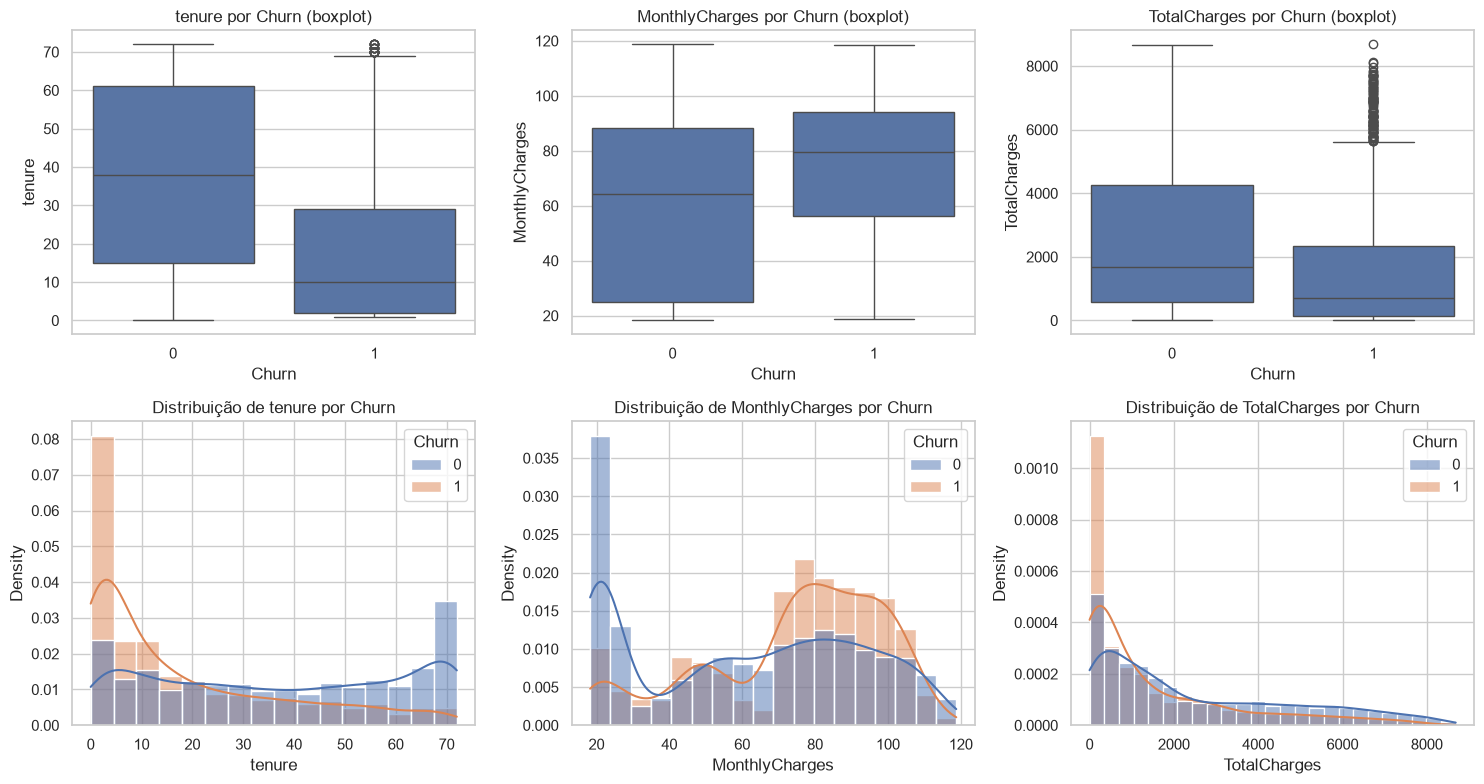

In [35]:
#num_cols já foi definido em 2.1, são as variáveis tenure, monthly charges e total charges

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    sns.boxplot(data=df_tratado, x="Churn", y=col, ax=axes[0, i])
    axes[0, i].set_title(f"{col} por Churn (boxplot)")

    sns.histplot(
        data=df_tratado, x=col, hue="Churn",
        stat="density", common_norm=False, kde=True,
        ax=axes[1, i]
    )
    axes[1, i].set_title(f"Distribuição de {col} por Churn")

plt.tight_layout()
plt.show()

In [36]:
# correlação bruta entre as três
df_tratado[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


In [37]:
# TotalCharges deveria ser ~ tenure * MonthlyCharges se a cobrança fosse constante.
# A diferença mostra o quanto isso se sustenta na prática (descontos, mudança de plano, etc.)
total_implicito = df_tratado["tenure"] * df_tratado["MonthlyCharges"]
diff = df_tratado["TotalCharges"] - total_implicito

diff.describe()

count    7043.000000
mean        0.152953
std        67.202778
min      -370.850000
25%       -28.600000
50%         0.000000
75%        28.500000
max       373.250000
dtype: float64

In [38]:
# medianas por grupo, pra comparar com o que os boxplots mostraram visualmente
df_tratado.groupby("Churn")[num_cols].median()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,38.0,64.425,1679.525
1,10.0,79.650,703.550


Conclusões tiradas a partir dessas estatísticas e gráficos:

A variável tenure Mediana de 38 meses (não churn) contra 10 meses (churn). O boxplot mostra pouca sobreposição de IQR, e o histograma é ainda mais eloquente: densidade de ~0.08 no primeiro bin para quem cancela, contra ~0.023 para quem fica. Ou seja, o churn se concentra nos primeiros meses de vida do cliente.

Repare também na bimodalidade da curva azul (não churn): tem um pico em tenure baixo e outro em ~70 meses. Isso é o retrato de duas populações distintas — clientes novos que ainda não decidiram, e uma base fiel de longa data. Casa perfeitamente com o achado de Contract (2 anos = 2.8% de churn): o pico em 70 é provavelmente o mesmo grupo.

Um detalhe metodológico que vale registrar: tenure está truncado em 72 meses. Não é um problema para este projeto, mas é censura à direita.

MonthlyCharges — hipótese confirmada, porém efeito bem mais fraco
Mediana 79.65 (churn) vs 64.43 (não churn) é uma diferença real, na direção esperada. Mas os boxplots mostram sobreposição grande (IQR de churn ~56–94, de não churn ~25–88). Como preditor isolado, é inferior a tenure.

O mais interessante está no histograma: a curva azul tem um pico forte em ~20 que a laranja praticamente não tem. Esse pico é o segmento sem internet contratada (bate com InternetService = No, 7.4% de churn). É esse grupo barato e fiel que puxa a mediana de não-churn para baixo, ou seja, parte do "efeito preço" que você está vendo é na verdade o efeito de qual serviço a pessoa tem, não de quanto ela paga. A concentração de churners na faixa 70–110 é a região de fibra, o que fecha o círculo com o achado contra-intuitivo de InternetService.

TotalCharges teve redundância comprovada, e melhor do que a correlação sugeria
Aqui está o achado mais limpo. O diff.describe() mostra:

mediana exatamente 0.00
IQR de ±28.5, o que é menos de meio mês de cobrança (mediana de MonthlyCharges ≈ 70)
cauda de ±370, ou seja ~5 meses — os casos onde o cliente mudou de plano ao longo do contrato
Traduzindo: TotalCharges é, para o cliente típico, função determinística de tenure × MonthlyCharges. Não é "correlacionada com" — é praticamente reconstituível a partir das outras duas.

Isso expõe um ponto metodológico que vale ouro para você: a correlação de 0.826 com tenure subestima a redundância, porque correlação de Pearson mede relação linear e a relação real aqui é multiplicativa. Se você tivesse olhado só a matriz de correlação, teria concluído "alta, mas não altíssima — talvez valha manter". O teste do resíduo é que provou o caso.

Há ainda um agravante conceitual: TotalCharges mistura dois sinais que apontam em direções opostas para churn — tenure baixo aumenta o risco, mensalidade alta também aumenta, mas o produto das duas embaralha os dois efeitos. É por isso que a mediana de TotalCharges dos churners é menor (703 vs 1679): o efeito tenure domina e mascara o efeito preço. Uma variável que confunde dois sinais opostos é pior que qualquer uma das duas isoladas.

## 5 achados principais

1. TODO
2. TODO
3. TODO
4. TODO
5. TODO